In [16]:
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [53]:
nside = 64
lmax = 3*nside-1
Nlbin = 1

b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

instr_name='litebird_full'
instr =  np.load("../lib/instr_dict/%s.npy"%instr_name,allow_pickle=True).item()
sens_P = instr['sens_P']
Nfreqs = len(sens_P)
Npix = hp.nside2npix(nside)
sigpix= sens_P/(np.sqrt((4*np.pi)/Npix*(60*180/np.pi)**2))

Cl_noise = np.load('../e2e_simulations/CL_noise_fsky0.7_nside64_aposcale10.npy')[:, :, 1:, 2:3*nside]
N = len(Cl_noise)

Cl_noise_smooth = np.zeros_like(Cl_noise)
for i in range(N):
    for j in range(Nfreqs):
        for k in range(2):
            Cl_noise_smooth[i, j, k] = gaussian_filter(Cl_noise[i, j, k], sigma=1)

noise_mean = np.mean(Cl_noise, axis=(0,2))
noise_std = np.std(Cl_noise, axis=(0,2))

noise_mean_smooth = np.mean(Cl_noise_smooth, axis=(0,2))

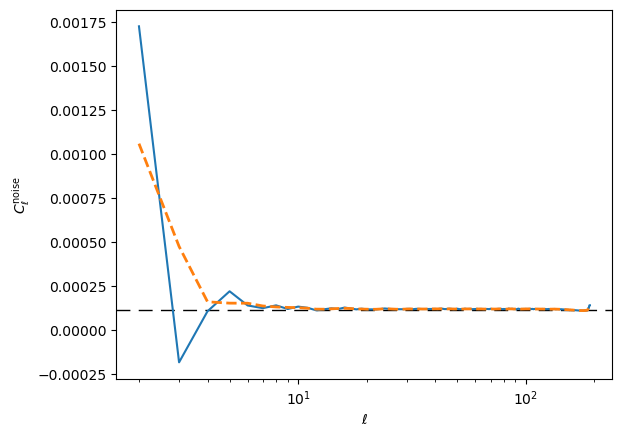

In [54]:
idx = 0

plt.axhline(4*np.pi/Npix * sigpix[idx]**2, ls=(0, (10,6)), lw=1, color='black')
plt.plot(leff, noise_mean[idx])
#plt.plot(leff, gaussian_filter(noise_mean[idx], sigma=2), '--', lw=2)
plt.plot(leff, noise_mean_smooth[idx], '--', lw=2)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{\rm noise}$')
plt.xscale('log')
#plt.yscale('log')
plt.show()